# Introduction to LLMs with LangChain


<img src="https://heidloff.net/assets/img/2023/02/transformers.png">

Everything started with the Transformer architecture, introduced in the paper “Attention Is All You Need”. BERT (Bidirectional Encoder Representations from Transformers) was one of the first major models built on top of this architecture and played a key role in advancing natural language understanding. Modern generative AI models such as ChatGPT, Gemma, and Claude are also based on the Transformer architecture.

The main difference between Transformers and older text generation models lies in their ability to understand the context of each token in a sentence. While traditional RNN-based models tend to lose contextual information in long sequences, Transformers can maintain long-range dependencies, even in large textual contents such as financial documents, web pages, or books.

# LangChain

LangChain is a framework for building applications powered by large language models (LLMs), making it easier to connect models with data, tools, and workflows.

https://docs.langchain.com/

In [1]:
import os
import json
import sys

import gymnasium as gym
import numpy as np


from mcp import StdioServerParameters, ClientSession
from mcp.client.stdio import stdio_client
from langchain_mcp_adapters.tools import load_mcp_tools


from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from langgraph.graph.message import REMOVE_ALL_MESSAGES
from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent, AgentState
from langchain.agents.middleware import before_model
from langchain_core.runnables import RunnableConfig
from langchain.tools import tool, ToolRuntime
from langchain.messages import RemoveMessage
from langgraph.runtime import Runtime

from pydantic import BaseModel, Field

from matplotlib import pyplot as plt

from typing import Any

# Example 1: Who wants to be a Millionare!

<img src="https://upload.wikimedia.org/wikipedia/en/c/cc/WWTBAM20thTitle.png">

Our first project should be a very basic example of using LLM.<br>
We are going to create the game show "Who wants to be a Millionare", and we will have a host and a contestant in a question/answer iteraction!

In [2]:
model = ChatOpenAI(model="gpt-5-nano", temperature=0.1)

# AN OPENAI_API_KEY environment variable is required to run this notebook.
os.environ["OPENAI_API_KEY"][:15]

'sk-proj-nGRdxqG'

In [273]:
host_prompt = """
You are the host of a game show inspired by "Who Wants to Be a Millionaire?".

Your job is to:
- Ask one multiple choice question at a time
- Provide 4 options labeled A, B, C, D
- Clearly indicate which option is correct in a structured JSON format
- Be dramatic and engaging like an American TV host

IMPORTANT:
- Do not reveal the correct answer in the question text.
- Output must be valid JSON.

Output format:

**Question**: "Your question text here"
**Options**:
- A: "Option A text"
- B: "Option B text"
- C: "Option C text"
- D: "Option D text"
**Answer**: "Correct option letter (A, B, C, or D)"
"""

contestant_prompt = """
You are a contestant on a high-stakes American quiz show.

You will receive:
- A question
- Four answer choices (A, B, C, D)

You must:
- Think briefly
- Choose one option
- Respond ONLY in JSON format

You are intelligent but not perfect.
Sometimes you may answer incorrectly.

Output format:
**Answer**: "Your chosen option letter (A, B, C, or D)"

Question:
"""

In [274]:
response = model.invoke(host_prompt)
print(response)

content='{\n  "Question": "Ladies and gentlemen, welcome to the ultimate test of knowledge! Ready to play for glory? Which city is world-renowned for its winding canals and iconic gondolas?",\n  "Options": {\n    "A": "Venice, Italy",\n    "B": "Amsterdam, Netherlands",\n    "C": "Bangkok, Thailand",\n    "D": "St. Petersburg, Russia"\n  },\n  "Answer": "A"\n}' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 1254, 'prompt_tokens': 168, 'total_tokens': 1422, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1152, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DF8RarmWcUnzrRJLuy2Wl09jjmFGB', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019cb137-ed30-7811-aaf5-ce88141230a0-0' tool_calls=[] invali

In [275]:
response_json = json.loads(response.content)
print(json.dumps(response_json, indent=4))

{
    "Question": "Ladies and gentlemen, welcome to the ultimate test of knowledge! Ready to play for glory? Which city is world-renowned for its winding canals and iconic gondolas?",
    "Options": {
        "A": "Venice, Italy",
        "B": "Amsterdam, Netherlands",
        "C": "Bangkok, Thailand",
        "D": "St. Petersburg, Russia"
    },
    "Answer": "A"
}


In [276]:
response = model.invoke(contestant_prompt + response_json["Question"])
response_content = response.content


In [277]:

response_content

'{"Answer": "A"}'

## Adding an Output Parser

In [278]:
model_with_output_parser = model | StrOutputParser()
response = model_with_output_parser.invoke(contestant_prompt + response_json["Question"])
print(response)

{"Answer": "B"}


In [279]:
class HostQuestion(BaseModel):
    question: str = Field(..., description="The question text", alias="Question")
    options: dict = Field(..., description="A dictionary of options with keys A, B, C, D", alias="Options")
    answer: str = Field(..., description="The correct option letter (A, B, C, or D)", alias="Answer")

class ContestantAnswer(BaseModel):
    answer: str = Field(..., description="The contestant's selected option letter (A, B, C, or D)", alias="Answer")

In [280]:
host_model = model | PydanticOutputParser(pydantic_object=HostQuestion)
host_response = host_model.invoke(host_prompt)
print(host_response.model_dump_json(indent=4))

{
    "question": "Ladies and gentlemen, step right up! For your next challenge, which of the following is the largest planet in our Solar System by volume?",
    "options": {
        "A": "Jupiter",
        "B": "Saturn",
        "C": "Uranus",
        "D": "Neptune"
    },
    "answer": "A"
}


In [281]:
contestant_model = model | PydanticOutputParser(pydantic_object=ContestantAnswer)
contestant_response = contestant_model.invoke(contestant_prompt + host_response.question)
print(contestant_response.model_dump_json(indent=4))

{
    "answer": "A"
}


## Adding Prompt Templates

In [282]:
host_prompt = ChatPromptTemplate.from_messages([
    ( 
        "system",
        """
        You are the host of a game show inspired by "Who Wants to Be a Millionaire?".
        Your job is to:
        - Ask one multiple choice question at a time
        - Provide 4 options labeled A, B, C, D
        - Clearly indicate which option is correct in a structured JSON format
        - Be dramatic and engaging like an American TV host
        - The difficulty of the question should be appropriate for a contestant who is intelligent but not perfect.
        - The difficulty should be in increasing order as the game progresses.
        
        IMPORTANT:
        - Do not reveal the correct answer in the question text.
        - Output must be valid JSON.

        The current question is number {question_number} in the game.

        {output_format_instructions}
        """
    ),
])

host_output_parser = PydanticOutputParser(pydantic_object=HostQuestion)

host_model = host_prompt | model | host_output_parser
host_response = host_model.invoke({ "question_number": 0, "output_format_instructions": host_output_parser.get_format_instructions() })

print(host_response.model_dump_json(indent=4))

{
    "question": "Ladies and gentlemen, it's time for your first challenge! What is the chemical formula for water?",
    "options": {
        "A": "H2O",
        "B": "CO2",
        "C": "NaCl",
        "D": "O2"
    },
    "answer": "A"
}


In [283]:
contestant_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        You are a contestant on a high-stakes American quiz show.
        You will receive:
        - A question
        - Four answer choices (A, B, C, D)

        You must:
        - Think briefly
        - Choose one option
        - Respond ONLY in JSON format

        You are intelligent but not perfect. 
        You can fail to answer correctly in 5 percent of the questions.

        {output_format_instructions}

        Question:
        {question}

        Options:
        {options}
        """
    ),
])

contestant_output_parser = PydanticOutputParser(pydantic_object=ContestantAnswer)
contestant_model = contestant_prompt | model | contestant_output_parser
contestant_response = contestant_model.invoke({ 
    "output_format_instructions": contestant_output_parser.get_format_instructions(), 
    "question": host_response.question, 
    "options": host_response.options 
})
print(contestant_response.model_dump_json(indent=4))

{
    "answer": "A"
}


In [284]:
for question in range(1, 5):
    
    host_response = host_model.invoke({ "question_number": question, "output_format_instructions": host_output_parser.get_format_instructions() })
    print(f"Host: {host_response.question}")
    print("Options:")
    for option_key, option_text in host_response.options.items():
        print(f"\t{option_key} {'*' if option_key == host_response.answer else ' '}: {option_text}")


    contestant_response = contestant_model.invoke({ 
        "output_format_instructions": contestant_output_parser.get_format_instructions(), 
        "question": host_response.question,
        "options": host_response.options
    })
    print(f"Contestant: {contestant_response.answer}")

    if contestant_response.answer == host_response.answer:
        print("Contestant is correct!")
    else:
        print("Contestant is incorrect.")
        break

Host: Ladies and gentlemen, for Question 1 under the blazing stage lights: which gas do plants primarily absorb for photosynthesis?
Options:
	A  : Oxygen
	B *: Carbon dioxide
	C  : Nitrogen
	D  : Methane
Contestant: B
Contestant is correct!
Host: Step up to the hotseat for Question 2! Which of the following is NOT a programming language?
Options:
	A  : Python
	B  : Java
	C *: HTML
	D  : C++
Contestant: C
Contestant is correct!
Host: Ladies and gentlemen, for question 3: Which planet has the longest rotation period, taking roughly 243 Earth days to complete one rotation?
Options:
	A  : Earth
	B  : Mars
	C *: Venus
	D  : Mercury
Contestant: C
Contestant is correct!
Host: Four questions in, folks—here's a real test: in a sorted array, what is the time complexity of performing a binary search?
Options:
	A  : O(n)
	B *: O(log n)
	C  : O(n log n)
	D  : O(1)
Contestant: B
Contestant is correct!


# Example 2: Frozen Lake!

We are going to use tools to ask our LLM to play a game called "Frozen Lake".

This game is part of a library to work with AI, specially reinforcement learning, called [Gymnasium](https://gymnasium.farama.org/index.html)!

<img src="https://gymnasium.farama.org/_images/frozen_lake.gif">


In [285]:
env = gym.make("FrozenLake-v1", render_mode="rgb_array", is_slippery=False)
# https://gymnasium.farama.org/environments/toy_text/frozen_lake/

Observation: 4, Reward: 0, Terminated: False, Truncated: False, Info: {'prob': 1.0}


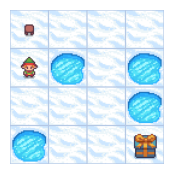

In [286]:
obs, info = env.reset()
observation, reward, terminated, truncated, inf = env.step(1)

img = env.render()

plt.figure(figsize=(2,2))
plt.axis('off')
plt.imshow(img)

print(f"Observation: {observation}, Reward: {reward}, Terminated: {terminated}, Truncated: {truncated}, Info: {inf}")

In [287]:
def state_as_text(env:gym.Env, state:int):
    map = np.array(env.unwrapped.desc).flatten().astype(str)
    map[state] = "*"
    map.reshape(4,4)
    return "\n".join([" | ".join(row) for row in map.reshape(4,4)])

print(state_as_text(env, 3))

S | F | F | *
F | H | F | H
F | F | F | H
H | F | F | G


In [288]:
class Action(BaseModel):
    """
    Represents an action taken by the agent in the FrozenLake environment.
    """
    action:int = Field(..., description="The action to take (0=Left, 1=Down, 2=Right, 3=Up)")

images = []

@tool
def step(action:Action):
    """
    Takes a step in the FrozenLake environment using the given action.
    """
    observation, _, terminated, _, _ = env.step(action.action)
    
    img = env.render()
    images.append(img)
    
    state = state_as_text(env, observation)
    response = {
        "terminated": terminated,
        "state": state
    }

    return json.dumps(response)

In [ ]:
frozen_lake_agent_prompt = """
You are an agent navigating a FrozenLake environment.
The environment is a 4x4 grid.

Every spot in the map has a character who is either:
- S: Starting point (safe)
- F: Frozen surface (safe)
- H: Hole (terminates the episode with failure)
- G: Goal (terminates the episode with success)
- *: Your current position

For every step, you should:
1. check the current state of the environment (the map with your position)
2. decide on an action to take
3. use the tool to take that action in the environment
4. observe the new state and whether the episode has terminated

The slipping is turned off, so your actions will always succeed.
Your goal is to reach the G spot on the map, avoiding H spots, starting from S.

You have access to tools to interact with the environment.
If the tool returns "terminated": true, it means the episode has ended (either by falling into a hole or reaching the goal).

The first message you receive will be the initial state of the environment.
"""


class FrozenLakeAgentResponse(BaseModel):
    """
    Represents the response from the FrozenLake agent after taking an action.
    """
    could_get_the_goal: bool = Field(..., description="Whether the agent successfully reached the goal")
    comments: str = Field(..., description="Any additional comments or reasoning about the actions taken")

agent = create_agent(
    model=model,
    tools=[step],
    response_format=FrozenLakeAgentResponse,
    system_prompt=frozen_lake_agent_prompt,
    debug=True,
)

images.clear()
observation, _ = env.reset()

state = state_as_text(env, observation)

response = agent.invoke({ "messages": [ { "role": "user", "content": state } ] })

print(response["structured_response"].model_dump_json(indent=4))

[values] {'messages': [HumanMessage(content='* | F | F | F\nF | H | F | H\nF | F | F | H\nH | F | F | G', additional_kwargs={}, response_metadata={}, id='6705a10c-190d-4d6f-ac78-5b6f37051935')]}


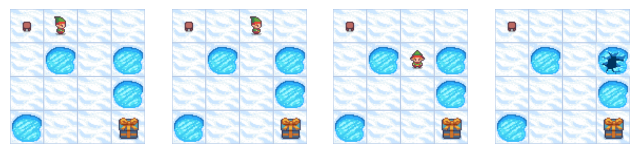

In [ ]:
total_images = len(images)

width = max(total_images, 8)
height = max(total_images / 2, 4)

rows = max(total_images // 4, 1)
cols = min(total_images, 4)

fig, axis = plt.subplots(rows, cols)
fig.set_size_inches(width, height)
axis = axis.flatten() if total_images > 1 else [axis]

for img, ax in zip(images, axis):
    ax.imshow(img)
    ax.axis('off')

# Example 3: Agent Memory

Some times we need the LLM to remember previuous messages. We need to add memory capabilities to it.

In [ ]:
agent = create_agent(
    model=model
)

In [ ]:
response = agent.invoke({ "messages": [ { "role": "user", "content": "My name is Jonathan" } ] })
print(response["messages"][-1].content)

print("------")

response = agent.invoke({ "messages": [ { "role": "user", "content": "What is my name?" } ] })
print(response["messages"][-1].content)

Nice to meet you, Jonathan! How can I help you today? If you’d like, I can use your name in our chat or tailor responses to your goals—tell me what you want to work on.
------
I don’t know your name unless you share it. If you tell me a name or a nickname, I’ll use it. What would you like me to call you?


In [ ]:
agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(),
)

In [ ]:
response = agent.invoke(
    { "messages": [ { "role": "user", "content": "My name is Jonathan" } ] },
    {"configurable": {"thread_id": "1"}},
)
print(response["messages"][-1].content)

print("------")

response = agent.invoke(
    { "messages": [ { "role": "user", "content": "What is my name?" } ] },
    {"configurable": {"thread_id": "1"}},
)
print(response["messages"][-1].content)

Nice to meet you, Jonathan! How can I help today? If you’d like, I can refer to you as Jonathan in this chat.

What would you like to work on? Here are some things I can help with:
- Answer questions or explain concepts
- Help with writing, editing, or brainstorming
- Coding, math, or problem solving
- Plan projects or study schedules
- Learn something new with examples and practice
- Create checklists, resumes, emails, or messages
- Language practice or interview prep

Tell me what you’re working on or what you’d like to achieve, and we’ll go from there.
------
Your name is Jonathan. I’ll keep referring to you as Jonathan unless you’d prefer a nickname or something else. How can I help you today?


With short-term memory enabled, long conversations can exceed the LLM’s context window.<br>
Common solutions are:

* Trim Messages
* Delete messages
* Summarize Messages
* Custom strategies

see more at: https://docs.langchain.com/oss/python/langchain/short-term-memory

In [ ]:
@before_model
def trim_messages(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Keep only the last few messages to fit context window."""
    messages = state["messages"]

    if len(messages) <= 3:
        return None  # No changes needed

    first_msg = messages[0]
    recent_messages = messages[-3:] if len(messages) % 2 == 0 else messages[-4:]
    new_messages = [first_msg] + recent_messages

    return {
        "messages": [
            RemoveMessage(id=REMOVE_ALL_MESSAGES),
            *new_messages
        ]
    }


agent = create_agent(
    model=model,
    middleware=[trim_messages],
    checkpointer=InMemorySaver(),
)

In [ ]:
config: RunnableConfig = {"configurable": {"thread_id": "1"}}

agent.invoke({"messages": "hi, my name is Jonathan"}, config)
agent.invoke({"messages": "write a short poem about cats"}, config)
agent.invoke({"messages": "now do the same but for dogs"}, config)
final_response = agent.invoke({"messages": "what's my name?"}, config)

print(final_response["messages"][-1].content)

Jonathan. Would you like me to keep using that, or do you have a nickname you’d prefer?


# Example 4: RAG

RAG is extra context you include in the chat as information for LLM. In this example we are using informartion about a movie, but we can add data from reports, documents or any other source.

**Now we can try something more advanced!**

In [16]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_openai import OpenAIEmbeddings

loader = WebBaseLoader("https://en.wikipedia.org/wiki/Ghostbusters")
docs = loader.load()
docs = [doc.page_content for doc in docs if len(doc.page_content) > 0]

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
all_splits = text_splitter.create_documents(docs)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vector_store = InMemoryVectorStore(embedding=embeddings)
vector_store.add_documents(all_splits)


@tool(response_format="content_and_artifact")
def retrieve_context(query: str):
    """Retrieve information to help answer a query."""
    retrieved_docs = vector_store.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs



prompt = """
You have access to a tool that retrieves context from a wikipedia page.
Use the tool to help answer user queries.
"""

agent = create_agent(
    model=model, 
    tools=[retrieve_context],
    system_prompt=prompt,
    debug=True,
)

response = agent.invoke({
    "messages": [
        {"role": "user", "content": "List the actors in the movie Ghostbusters and the characters they played."}
    ]
})

for m in response["messages"]:
    m.pretty_print()


[values] {'messages': [HumanMessage(content='List the actors in the movie Ghostbusters and the characters they played.', additional_kwargs={}, response_metadata={}, id='7df9f7ce-99da-49e1-95bb-e7b368d9c3df')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 669, 'prompt_tokens': 166, 'total_tokens': 835, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 640, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DHfHr4NpHRE5CB6nLiPDQG0PkkIg2', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cd527-8793-7e22-a860-f6114a8edc95-0', tool_calls=[{'name': 'retrieve_context', 'args': {'query': 'Ghostbusters (1984) cast'}, 'id': 'call_t1KfBKKbIG89

RAG usually uses vector dbs like [chroma](https://www.trychroma.com/) to store and query text by similatity.

# Example 5: Deep Agents

In [1]:
from deepagents import create_deep_agent
from deepagents.backends.utils import create_file_data

In [3]:
def get_course_modules():
    "Returns a list of course modules with their details."
    return [
        dict(id=1, title="virtual environments", difficulty="easy", est_hours=1),
        dict(id=2, title="Basic Python", difficulty="easy", est_hours=2),
        dict(id=3, title="Data analysis", difficulty="medium", est_hours=3),
        dict(id=4, title="Introduction to machine learning", difficulty="medium", est_hours=3),
        dict(id=5, title="Introduction to deep learning", difficulty="hard", est_hours=4),
        dict(id=6, title="Introduction to LLMs", difficulty="medium", est_hours=4)
    ]

def get_student_profile(name:str, daily_minutes:int):
    "Returns a student profile with the given name and daily study time."
    return dict(
        name=name,
        daily_minutes=daily_minutes,
        goal="Understand the basics of AI and machine learning, and be able to build simple projects by myself."
    )

def estimate_daily_capacity(daily_minutes:int):
    "Estimates the daily learning capacity in low, medium, and high categories."
    if daily_minutes < 45:
        return "low"
    if daily_minutes < 90:
        return "medium"
    return "high"

In [4]:
class StudyDay(BaseModel):
    day:int = Field(..., description="The day number in the study plan")
    focus:str = Field(..., description="The focus of the day, e.g. 'virtual environments'")
    tasks:list[str] = Field(..., description="A list of tasks to complete on this day")
    expected_minutes:int = Field(..., description="The expected number of minutes to spend on this day")

class StudyPlan(BaseModel):
    student_name: str
    duration_days: int
    strategy: str
    days: list[StudyDay]
    risks: list[str]
    success_criteria: list[str]

In [5]:
main_skill = """---
name: study-orchestrator
description: Use this skill when asked by a studding plan with prioritizarion and risks
---

# study-orchestrator

## Objective
Transform a studding objective in a realistic daily plan.

## Instructions
1. Get the student profile.
2. Forward the sequence details to the subagent curriculum-designer.
3. Forward the revision to the subagent reviewer.
4. Return the final study plan.
"""

curriculum_skill = """---
name: curriculum-sequencing
description: Sequence the course modules in a progressive way, taking into account the student's profile and the module details.
---

# curriculum-sequencing

## Rules
1. Start from fundamental concepts and gradually move to more complex ones.
2. Then analisys and ML
3. Then deep learning and LLMs
4. Aways respect the daily capacity of the student.
"""

reviewer_skill = """---
name: plan-quality-check
description: Review the study plan, looking for overload, underloading and risks.
---

# plan-quality-check

## Checklist
1. There is any overloaded day?
2. The plan respects the difficult progression principle?
3. There are clear risks and success criteria defined?
4. Suggest improvements if any of the above points are not met.
"""

files = {
    "/skills/main/study-orchestrator/SKILL.md": create_file_data(main_skill),
    "/skills/subagents/curriculum/SKILL.md": create_file_data(curriculum_skill),
    "/skills/subagents/reviewer/SKILL.md": create_file_data(reviewer_skill),
}

In [8]:
subagents = [
    {
        "name": "curriculum-designer",
        "description": "Specialist in designing study curriculums",
        "system_prompt": "You designs progressive and realistic study plans.",
        "tools": [ get_course_modules, estimate_daily_capacity ],
        "model": model,
        "skills": [ "/skills/subagents/curriculum/" ]
    },
    {
        "name": "reviewer",
        "description": "Specialist in reviewing study plans and providing feedback",
        "system_prompt": "You review study plans looking for overload, underloading and risks.",
        "tools": [ estimate_daily_capacity ],
        "model": model,
        "skills": [ "/skills/subagents/reviewer/" ]
    }
]

In [9]:
agent = create_deep_agent(
    model=model,
    tools=[get_course_modules, get_student_profile, estimate_daily_capacity],
    system_prompt=(
        "You are a study plan generator. "
        "Use subagents when the task requires details and revision. "
        "Deliver an executable plan with a clear objective."
    ),
    subagents=subagents,
    skills=["/skills/main/"],
    response_format=StudyPlan
)

In [10]:
result = agent.invoke({
    "messages": [
        { "role": "user", "content": "I need a 7 days, 60 minutes per day, study plan covering all modules"}
    ],
    "files": files,
})

In [11]:
print(result["structured_response"].model_dump_json(indent=4))

{
    "student_name": "Learner",
    "duration_days": 7,
    "strategy": "7-day plan with 60-minute daily sessions that touch each module once, starting from environment setup and Python basics, then moving through data analysis, ML, DL, and LLMs, finishing with cross-module synthesis and next steps. Emphasizes practical exercises and quick wins to establish a foundation for deeper study in subsequent weeks.",
    "days": [
        {
            "day": 1,
            "focus": "Module: Virtual Environments (environment setup)",
            "tasks": [
                "Create and activate a Python virtual environment (venv or Conda)",
                "Set up a course project directory with a README",
                "Review overview of Module 2 Basic Python to prepare upcoming days",
                "Run a simple 'Hello, World!' script to verify setup"
            ],
            "expected_minutes": 60
        },
        {
            "day": 2,
            "focus": "Module: Basic Python (c

# Example 6. MCPs

MCPs are like tools, but accessible throught internet (or stdio).

The smithery is a gateway with many different mcps, you can take a look :)<br>
https://smithery.ai/

In [3]:
server = StdioServerParameters(
    command="uvx",
    args=[ "mcp-server-git" ],
)

model = ChatOpenAI(model="gpt-5-nano", temperature=0.1)

async with stdio_client(server, errlog=sys.__stderr__) as (read, write):
    async with ClientSession(read, write) as session:
        await session.initialize()
        tools = await load_mcp_tools(session)
        print([t.name for t in tools])

        agent = create_agent(
            model=model,
            tools=tools,
            debug=True,
        )

        response = await agent.ainvoke({ "messages": [ { "role": "user", "content": "show the git history." } ] })
        print(response["messages"][-1].content)

['git_status', 'git_diff_unstaged', 'git_diff_staged', 'git_diff', 'git_commit', 'git_add', 'git_reset', 'git_log', 'git_create_branch', 'git_checkout', 'git_show', 'git_branch']
[values] {'messages': [HumanMessage(content='show the git history.', additional_kwargs={}, response_metadata={}, id='b1fb6f32-a288-4aa9-9c1d-9f7e15133337')]}
[updates] {'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 607, 'prompt_tokens': 734, 'total_tokens': 1341, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 576, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DMksTFPoVdf4Zdqmw7YWfd81gKgtG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d1d76-7427-7e52-8b75-8

Evaluation (Evals)
Criar métricas e testes automáticos para qualidade, factualidade, formato e regressão. Sem eval, evolução de app LLM vira tentativa e erro.

Observability e Tracing
Instrumentar fluxo com LangSmith ou similar para ver latência, custo, tool calls, falhas e alucinações por etapa.

Guardrails e Segurança
Validação de entrada/saída, políticas de conteúdo, proteção contra prompt injection, sanitização de tool inputs e data leakage.

Context Engineering
Chunking, reranking, query rewriting, compressão de contexto, janela de contexto e estratégia de memória por tipo de tarefa.

Confiabilidade de Tool Calling
Schemas robustos, retries, fallbacks, timeouts, circuit breakers e tratamento de erros em ferramentas externas.

Human-in-the-Loop (HITL)
Pontos de aprovação humana para ações sensíveis e revisão assistida de saídas críticas.

Custo e Performance
Model routing (modelo barato vs premium), caching semântico, batching, streaming e otimização de tokens.

Arquitetura de Produção
Versionamento de prompts, estratégias de rollout, monitoramento contínuo, incident response e governança.